In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.calibration import calibration_curve

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../data/processed/loan_data_engineered.csv')

In [4]:
drop_cols = ['loan_status', 'default', 'earliest_cr_line']
X = df.drop(columns=drop_cols)
y = df['default']

In [5]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

C:\Users\ARYAN DASH\AppData\Local\Temp\ipykernel_16832\3967489894.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
final_model = joblib.load('../models/tuned_lightgbm.pkl')

In [8]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")

Test AUC: 0.7272


In [11]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')

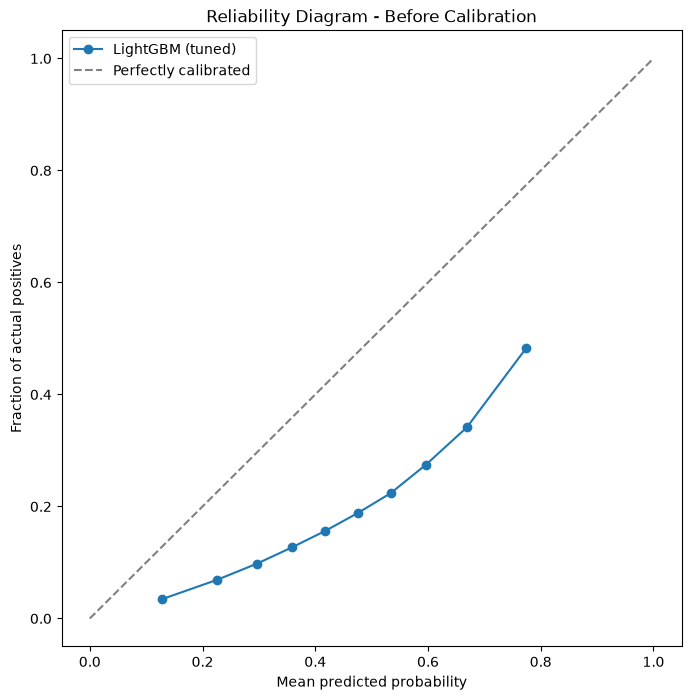

In [13]:
plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='o', label='LightGBM (tuned)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual positives')
plt.title('Reliability Diagram - Before Calibration')
plt.legend()
plt.savefig('../reports/figures/reliability_before_calibration.png')
plt.show()

In [14]:
from sklearn.calibration import CalibratedClassifierCV

In [16]:
import sklearn
print(sklearn.__version__)

1.9.0


In [17]:
from sklearn.frozen import FrozenEstimator

calibrated_platt = CalibratedClassifierCV(FrozenEstimator(final_model), method='sigmoid')
calibrated_isotonic = CalibratedClassifierCV(FrozenEstimator(final_model), method='isotonic')

In [18]:
X_calib, X_final_test, y_calib, y_final_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(X_calib.shape, X_final_test.shape)

(134535, 47) (134535, 47)


In [19]:
calibrated_platt.fit(X_calib, y_calib)
calibrated_isotonic.fit(X_calib, y_calib)

print("Both calibrators fit")

Both calibrators fit


In [20]:
y_pred_proba_platt = calibrated_platt.predict_proba(X_final_test)[:, 1]
y_pred_proba_isotonic = calibrated_isotonic.predict_proba(X_final_test)[:, 1]
y_pred_proba_uncalibrated = final_model.predict_proba(X_final_test)[:, 1]

auc_platt = roc_auc_score(y_final_test, y_pred_proba_platt)
auc_isotonic = roc_auc_score(y_final_test, y_pred_proba_isotonic)
auc_uncalibrated = roc_auc_score(y_final_test, y_pred_proba_uncalibrated)

In [21]:
print(f"Uncalibrated AUC: {auc_uncalibrated:.4f}")
print(f"Platt-calibrated AUC: {auc_platt:.4f}")
print(f"Isotonic-calibrated AUC: {auc_isotonic:.4f}")

Uncalibrated AUC: 0.7258
Platt-calibrated AUC: 0.7258
Isotonic-calibrated AUC: 0.7256


In [22]:
prob_true_uncal, prob_pred_uncal = calibration_curve(y_final_test, y_pred_proba_uncalibrated, n_bins=10, strategy='quantile')
prob_true_platt, prob_pred_platt = calibration_curve(y_final_test, y_pred_proba_platt, n_bins=10, strategy='quantile')
prob_true_iso, prob_pred_iso = calibration_curve(y_final_test, y_pred_proba_isotonic, n_bins=10, strategy='quantile')

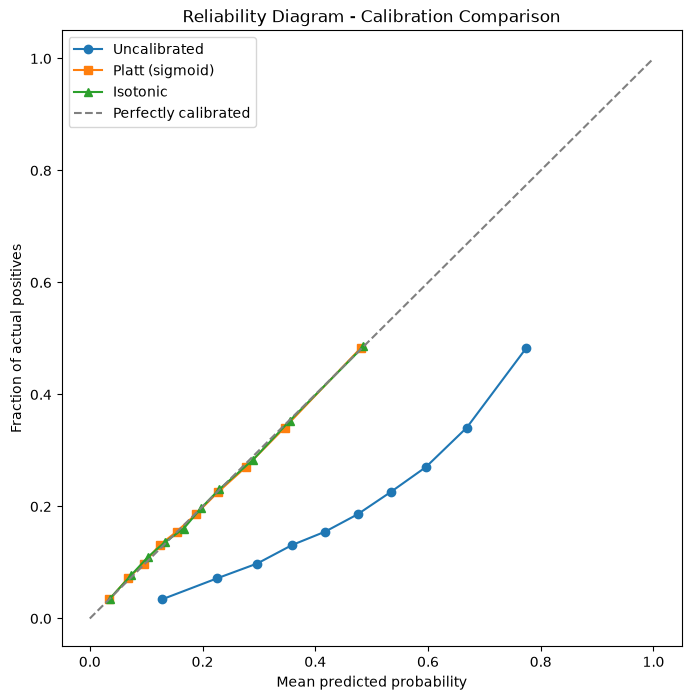

In [23]:
plt.figure(figsize=(8, 8))
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='Uncalibrated')
plt.plot(prob_pred_platt, prob_true_platt, marker='s', label='Platt (sigmoid)')
plt.plot(prob_pred_iso, prob_true_iso, marker='^', label='Isotonic')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual positives')
plt.title('Reliability Diagram - Calibration Comparison')
plt.legend()
plt.savefig('../reports/figures/reliability_comparison.png')
plt.show()

In [24]:
joblib.dump(calibrated_platt, '../models/calibrated_platt.pkl')
joblib.dump(calibrated_isotonic, '../models/calibrated_isotonic.pkl')
print("Calibration models saved")

Calibration models saved
